Purpose: Understand the data (not modeling)
Structure:
🧩 Section 1: Setup

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("../data/processed/segmented_data.csv")

## Section 2: Data Overview

In [22]:
df.shape
df.info()
df.describe()
df.isnull().sum()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 31 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            50000 non-null  float64
 1   Gender                         50000 non-null  object 
 2   Country                        50000 non-null  object 
 3   City                           50000 non-null  object 
 4   Membership_Years               50000 non-null  float64
 5   Login_Frequency                50000 non-null  float64
 6   Session_Duration_Avg           50000 non-null  float64
 7   Pages_Per_Session              50000 non-null  float64
 8   Cart_Abandonment_Rate          50000 non-null  float64
 9   Wishlist_Items                 50000 non-null  float64
 10  Total_Purchases                50000 non-null  float64
 11  Average_Order_Value            50000 non-null  float64
 12  Days_Since_Last_Purchase       50000 non-null 

Age                              0
Gender                           0
Country                          0
City                             0
Membership_Years                 0
Login_Frequency                  0
Session_Duration_Avg             0
Pages_Per_Session                0
Cart_Abandonment_Rate            0
Wishlist_Items                   0
Total_Purchases                  0
Average_Order_Value              0
Days_Since_Last_Purchase         0
Discount_Usage_Rate              0
Returns_Rate                     0
Email_Open_Rate                  0
Customer_Service_Calls           0
Product_Reviews_Written          0
Social_Media_Engagement_Score    0
Mobile_App_Usage                 0
Payment_Method_Diversity         0
Lifetime_Value                   0
Credit_Balance                   0
Churned                          0
Signup_Quarter                   0
engagement_index                 0
risk_score                       0
value_score                      0
segment             

## Section 3: Target Variable
### How many customers churn overall?

In [23]:
df["Churned"].value_counts(normalize=True)


Churned
0    0.711
1    0.289
Name: proportion, dtype: float64

## Section 4: Geography
### Which countries have the highest customer churn?

In [35]:
df.groupby("Country")["Churned"].mean().sort_values(ascending=False)


Country
Australia    0.298941
Canada       0.293541
USA          0.290842
India        0.290148
Germany      0.288325
UK           0.287895
Japan        0.278257
France       0.272863
Name: Churned, dtype: float64

### This does not mean that 
Australia → 0.298941 has 29.89% churn rate
### This means 
Japan → 0.278257 has relatively less churn rate

## Section 5: Engagement Patterns

### Density (number of users) VS Login Frequency

This plot compares how often users log in, split into two groups:

🟢 Not Churned (Churned = 0)

🔴 Churned (Churned = 1)



🔹 X-axis → Login_Frequency

Further right = users log in more often

Further left = users log in less often

🔹 Y-axis → Density

Higher curve = more users around that login frequency


### Density (number of users) VS Session Duration

🔹 X-axis — Average Session Duration

Left side → short sessions

Right side → long sessions

🔹 Y-axis — Density

Higher curve = more users concentrated at that session duration




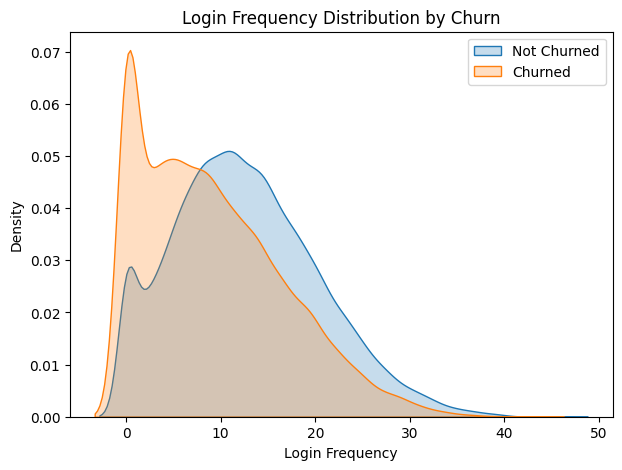

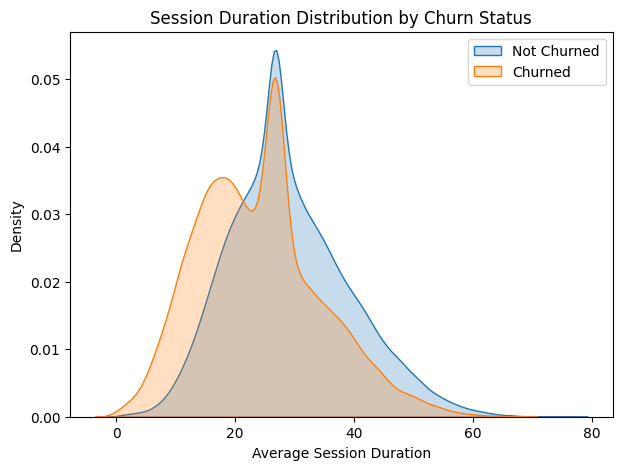

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))
sns.kdeplot(
    df[df["Churned"] == 0]["Login_Frequency"],
    label="Not Churned",
    fill=True
)

sns.kdeplot(
    df[df["Churned"] == 1]["Login_Frequency"],
    label="Churned",
    fill=True
)

plt.title("Login Frequency Distribution by Churn")
plt.xlabel("Login Frequency")
plt.legend()
plt.show()


import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))

sns.kdeplot(
    data=df[df["Churned"] == 0],
    x="Session_Duration_Avg",
    label="Not Churned",
    fill=True
)

sns.kdeplot(
    data=df[df["Churned"] == 1],
    x="Session_Duration_Avg",
    label="Churned",
    fill=True
)

plt.title("Session Duration Distribution by Churn Status")
plt.xlabel("Average Session Duration")
plt.ylabel("Density")
plt.legend()
plt.show()


## Section 6: Purchase Behavior
### Density (Number of Users) VS Days Since Last Purchase

🔹 X-axis: Days since last purchase

    Left → recent purchase

    Right → long inactivity

🔹 Y-axis: Density (how concentrated customers are)

### Density (Number of Users) VS Total Purchases

🔹 X-axis: Total number of purchases
    Left → Less purchases
    Right → More purchases

🔹 Y-axis: Density

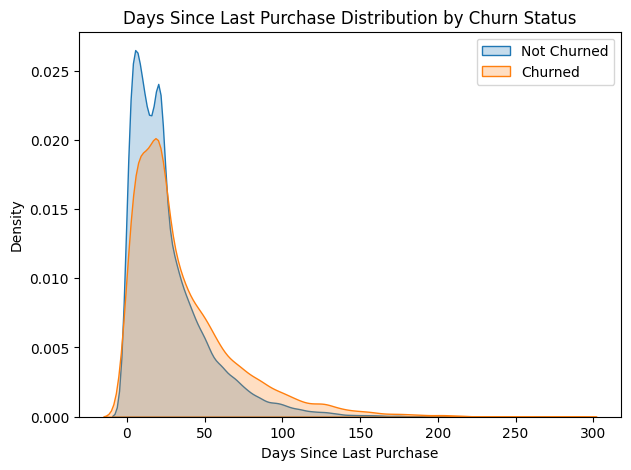

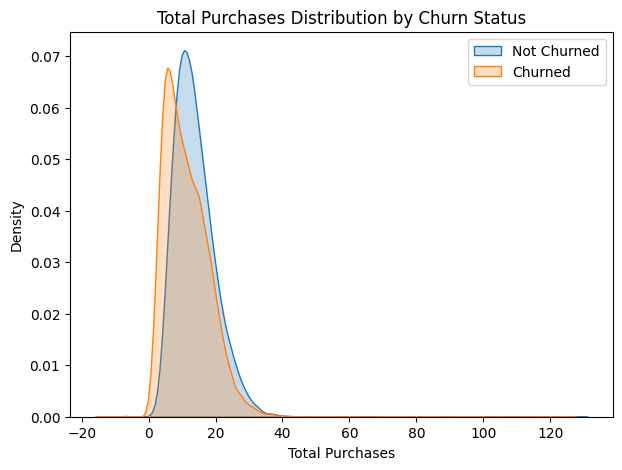

In [32]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7,5))

sns.kdeplot(
    data=df[df["Churned"] == 0],
    x="Days_Since_Last_Purchase",
    label="Not Churned",
    fill=True
)

sns.kdeplot(
    data=df[df["Churned"] == 1],
    x="Days_Since_Last_Purchase",
    label="Churned",
    fill=True
)

plt.title("Days Since Last Purchase Distribution by Churn Status")
plt.xlabel("Days Since Last Purchase")
plt.ylabel("Density")
plt.legend()
plt.show()


plt.figure(figsize=(7,5))

sns.kdeplot(
    data=df[df["Churned"] == 0],
    x="Total_Purchases",
    label="Not Churned",
    fill=True
)

sns.kdeplot(
    data=df[df["Churned"] == 1],
    x="Total_Purchases",
    label="Churned",
    fill=True
)

plt.title("Total Purchases Distribution by Churn Status")
plt.xlabel("Total Purchases")
plt.ylabel("Density")
plt.legend()
plt.show()


#### Density (Number of Users) VS Days Since Last Purchase
##### Key pattern

🔴 Churned curve is shifted to the right

🟢 Not-churned curve peaks near low values

##### Interpretation
Customers who churn tend to have longer gaps since their last purchase.

#### Density (Number of Users) VS Total Purchases
##### Key pattern
🔴 Churned customers cluster at low purchase counts

🟢 Not-churned customers have a long right tail

##### Interpretation
Customers with fewer total purchases are far more likely to churn.


## Section 7: Correlation
#### What this heatmap actually shows?
Which features are most positively or negatively related to churn?

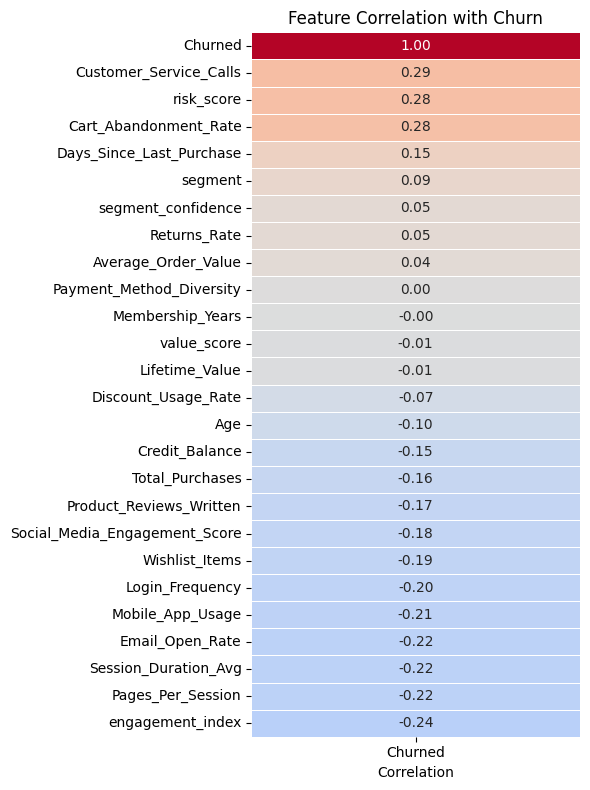

In [34]:
plt.figure(figsize=(6,8))

churn_corr = (
    df.corr(numeric_only=True)["Churned"]
    .sort_values(ascending=False)
    .to_frame()
)

sns.heatmap(
    churn_corr,
    annot=True,
    cmap="coolwarm",
    center=0,
    linewidths=0.5,
    fmt=".2f",
    cbar=False
)

plt.title("Feature Correlation with Churn")
plt.ylabel("")
plt.xlabel("Correlation")
plt.tight_layout()
plt.show()


#### How to read it:

🔴 Red (positive correlation)
→ Higher value = higher churn risk

🔵 Blue (negative correlation)
→ Higher value = lower churn risk

Near 0 (white)
→ Little linear relationship with churn